# Comparing Random Forest, AdaBoost and XGBoost
- Ayan Majumdar
- 251090051276

## Predicting hourly traffic volume
- Target column: traffic_volume

In [1]:
# Loading the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## Prepare the data
- Models can't read raw text or dates directly, so we fix two things:
- date_time is a string — we'll pull out the hour, day of week, and month.
- weather_main and holiday are text categories —we'll turn them into numbers the models can actually use.

In [2]:
# Extracting new columns from date_time column
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek   # Monday=0 ... Sunday=6
df['month'] = df['date_time'].dt.month
# For holiday column we just need to know YES or NO, so turn it into 1/0
df['is_holiday'] = df['holiday'].notna().astype(int)
# turn the weather category into separate 0/1 columns (one-hot encoding)
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)
# drop columns we no longer need
df = df.drop(columns=['holiday', 'weather_description', 'date_time'])
df.head()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,day_of_week,month,is_holiday,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,288.28,0.0,0.0,40,5545,9,1,10,0,True,False,False,False,False,False,False,False,False,False
1,289.36,0.0,0.0,75,4516,10,1,10,0,True,False,False,False,False,False,False,False,False,False
2,289.58,0.0,0.0,90,4767,11,1,10,0,True,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,5026,12,1,10,0,True,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,4918,13,1,10,0,True,False,False,False,False,False,False,False,False,False


## Split into training and test sets

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['traffic_volume'])
y = df['traffic_volume']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 38563
Test rows: 9641


## Random Forest 
- Builds many decision trees independently, each on a random slice of the data, then averages their predictions.


In [5]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest trained!")

Random Forest trained!


## AdaBoost 
- Builds trees one after another. Each new tree pays extra attention to the rows the earlier trees got most wrong, trying to fix those mistakes.

In [6]:
from sklearn.ensemble import AdaBoostRegressor

ab_model = AdaBoostRegressor(n_estimators=100, random_state=42)
ab_model.fit(X_train, y_train)
ab_preds = ab_model.predict(X_test)
print("AdaBoost trained!")

AdaBoost trained!


## XGBoost 
- A more refined, efficient version of the same "learn from mistakes" idea as AdaBoost, but smarter about exactly how much to correct after each round. 

In [9]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 1.8/69.5 MB 16.4 MB/s eta 0:00:05
   -- ------------------------------------- 3.7/69.5 MB 14.7 MB/s eta 0:00:05
   --- ------------------------------------ 5.2/69.5 MB 10.6 MB/s eta 0:00:07
   --- ------------------------------------ 6.3/69.5 MB 8.4 MB/s eta 0:00:08
   ---- ----------------------------------- 7.3/69.5 MB 8.0 MB/s eta 0:00:08
   ---- ----------------------------------- 8.1/69.5 MB 7.1 MB/s eta 0:00:09
   ---- ----------------------------------- 8.7/69.5 MB 7.3 MB/s eta 0:00:09
   ----- ---------------------------------- 8.9/69.5 MB 6.3 MB/s eta 0:00:10
   ----- ---------------------------------- 10.0/69.5 MB 5.6 MB/s eta 0:00:11
   ------ --------------------------------- 11.0/69.5 MB 5.4 MB/s eta 0:00:11
   ------ --------------------------------- 11.8/69.5 MB 5.3 MB/s eta 0:00:11
   ------- -------------------------------- 12.8/69.5 MB 5.3 MB/s eta 0:00:11

In [10]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("XGBoost trained!")

XGBoost trained!


## Which model did better?

Three simple prediction score:
- **MAE (Mean Absolute Error)** — Lower is better.
- **RMSE (Root Mean Squared Error)** — Lower is better.
- **R² Score** — From 0 to 1. Closer to 1 = better.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_scores(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5
    r2 = r2_score(actual, predicted)
    return {"Model": name, "MAE": round(mae, 1), "RMSE": round(rmse, 1), "R2 Score": round(r2, 3)}

results = pd.DataFrame([
    get_scores("Random Forest", y_test, rf_preds),
    get_scores("AdaBoost", y_test, ab_preds),
    get_scores("XGBoost", y_test, xgb_preds),
])
results

,Model,MAE,RMSE,R2 Score
0,Random Forest,252.3,457.6,0.947
1,AdaBoost,617.1,828.4,0.826
2,XGBoost,250.6,427.9,0.954


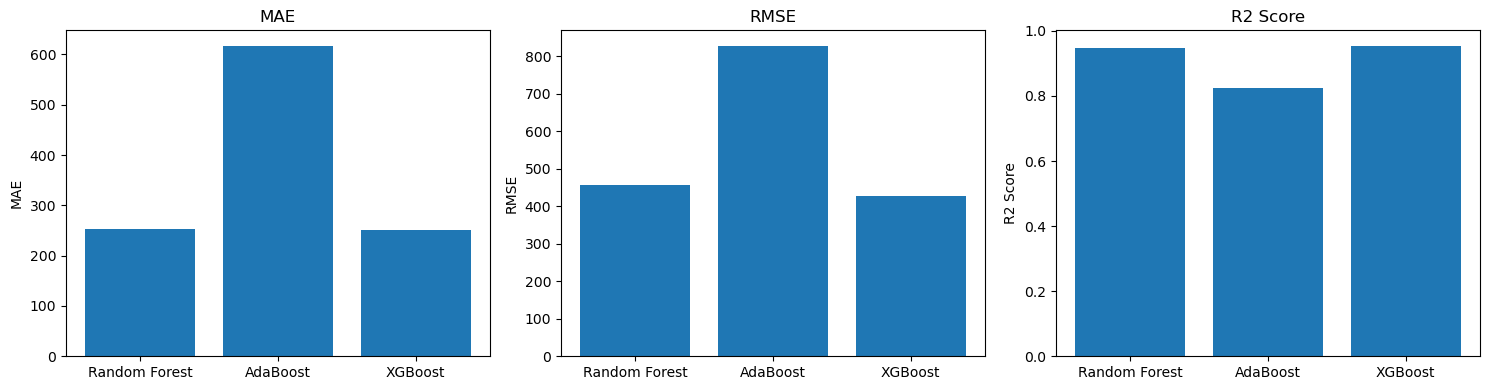

In [13]:
# A simple bar chart to see the comparison visually
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["MAE", "RMSE", "R2 Score"]):
    ax.bar(results["Model"], results[metric])
    ax.set_title(metric)
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

## Conclusion

Looking at the table and chart above:

- **AdaBoost** clearly performed the **worst** here (highest MAE/RMSE, lowest R²). AdaBoost corrects mistakes in a fairly simple, step-by-step way, so it tends to struggle when the data has lots of overlapping patterns to learn at once — like ours, where time-of-day, weather, and season all affect traffic together.
- **Random Forest** and **XGBoost** both did **much better**, and were close to each other — XGBoost coming out slightly ahead. This makes sense: both models can capture complex combinations of features well, and XGBoost's smarter mistake-correction gives it a small extra edge.

**Takeaway:** For this kind of dataset (lots of features interacting together), the more sophisticated ensembling approaches (Random Forest, XGBoost) clearly beat the simpler boosting approach (AdaBoost). XGBoost is the best performer overall here, with Random Forest a close second.